# Custom Isolation Forest with SHAP Explanations

This notebook demonstrates the use of the custom Isolation Forest implementation with SHAP (SHapley Additive exPlanations) to detect and explain anomalies in air quality data.

## Objectives:
1. Load and prepare the processed air quality dataset
2. Apply custom Isolation Forest implementation for anomaly detection
3. Integrate SHAP explanations to understand feature importance
4. Visualize and interpret the results

## 1. Import Required Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
from isolation_forest import IsolationTreeEnsemble

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

Libraries imported successfully!
SHAP version: 0.48.0


## 2. Load and Explore the Dataset

In [11]:
# Load the processed air quality data
df = pd.read_csv('../Data/unscaled_processed_airdata.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (9357, 16)

First few rows:


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Date_Time,Hour,Day,weekday
0,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,18,10,2
1,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,19,10,2
2,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,20,10,2
3,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,21,10,2
4,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,22,10,2


In [5]:
# Display dataset information
print("Dataset Information:")
print(df.info())
print("\nBasic Statistics:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   C6H6(GT)       9357 non-null   float64
 3   PT08.S2(NMHC)  9357 non-null   float64
 4   NOx(GT)        9357 non-null   float64
 5   PT08.S3(NOx)   9357 non-null   float64
 6   NO2(GT)        9357 non-null   float64
 7   PT08.S4(NO2)   9357 non-null   float64
 8   PT08.S5(O3)    9357 non-null   float64
 9   T              9357 non-null   float64
 10  RH             9357 non-null   float64
 11  AH             9357 non-null   float64
 12  Date_Time      9357 non-null   object 
 13  Hour           9357 non-null   int64  
 14  Day            9357 non-null   int64  
 15  weekday        9357 non-null   int64  
dtypes: float64(12), int64(3), object(1)
memory usage: 1.1+ MB
None

Basic Stati

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,Day,weekday
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,2.130603,1103.059741,10.179155,942.142620,241.922197,832.758897,109.632094,1453.298814,1032.544298,18.233408,49.191386,1.019621,11.498557,15.876884,3.009939
std,1.431736,218.196346,7.503812,267.866611,204.315075,255.709833,46.462311,343.206131,404.447613,8.781791,17.194506,0.402203,6.923182,8.808653,2.000323
min,0.100000,647.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700,0.000000,1.000000,0.000000
25%,1.100000,938.000000,4.500000,736.000000,96.000000,654.000000,76.000000,1227.000000,733.000000,11.700000,35.800000,0.732300,5.000000,8.000000,1.000000
50%,1.800000,1067.000000,8.300000,910.012987,180.000000,804.000000,104.917526,1460.000000,970.000000,17.600000,49.600000,0.989500,11.000000,16.000000,3.000000
75%,2.900000,1239.000000,14.100000,1119.000000,326.000000,968.000000,136.314685,1668.000000,1293.000000,24.300000,62.300000,1.306700,18.000000,23.000000,5.000000
max,11.900000,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,23.000000,31.000000,6.000000


## 3. Feature Engineering: Cyclical Time Features

We'll convert temporal features (Hour, Day, Weekday) into cyclical representations using sine and cosine transformations to better capture their periodic nature.

In [6]:
# Create cyclical features for temporal data
df['hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)

df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

print("Cyclical features created:")
print(df[['Hour', 'hour_sin', 'hour_cos', 'Day', 'day_sin', 'day_cos', 'weekday', 'weekday_sin', 'weekday_cos']].head())

Cyclical features created:
   Hour  hour_sin      hour_cos  Day   day_sin   day_cos  weekday  \
0    18 -1.000000 -1.836970e-16   10  0.897805 -0.440394        2   
1    19 -0.965926  2.588190e-01   10  0.897805 -0.440394        2   
2    20 -0.866025  5.000000e-01   10  0.897805 -0.440394        2   
3    21 -0.707107  7.071068e-01   10  0.897805 -0.440394        2   
4    22 -0.500000  8.660254e-01   10  0.897805 -0.440394        2   

   weekday_sin  weekday_cos  
0     0.974928    -0.222521  
1     0.974928    -0.222521  
2     0.974928    -0.222521  
3     0.974928    -0.222521  
4     0.974928    -0.222521  


## 4. Prepare Data for Modeling

In [7]:
# Prepare features for modeling (remove original time columns and Date_Time)
features_to_drop = ['Hour', 'Day', 'weekday', 'Date_Time']
df_features = df.drop(columns=features_to_drop)

print(f"Features for modeling: {list(df_features.columns)}")
print(f"Number of features: {df_features.shape[1]}")
print(f"Number of samples: {df_features.shape[0]}")

Features for modeling: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'weekday_sin', 'weekday_cos']
Number of features: 18
Number of samples: 9357


## 5. Train Custom Isolation Forest Model

We'll use our custom implementation of Isolation Forest for anomaly detection.

In [14]:
# Initialize and train the custom Isolation Forest
n_samples = df_features.shape[0]
sample_size = min(256, n_samples)  # Standard sample size for Isolation Forest
n_trees = 100  # Number of trees in the ensemble

print(f"Training Custom Isolation Forest...")
print(f"  Sample size: {sample_size}")
print(f"  Number of trees: {n_trees}")

# Create and fit the model
iso_forest = IsolationTreeEnsemble(sample_size=sample_size, n_trees=n_trees)
iso_forest.fit(df_features, improved=False)

print("\nModel trained successfully!")
print(f"Feature names stored: {iso_forest.get_feature_names()}")

Training Custom Isolation Forest...
  Sample size: 256
  Number of trees: 100

Model trained successfully!
Feature names stored: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'weekday_sin', 'weekday_cos']


## 6. Calculate Anomaly Scores and Detect Anomalies

In [9]:
# Calculate anomaly scores
anomaly_scores = iso_forest.anomaly_score(df_features)

print("Anomaly Score Statistics:")
print(f"  Range: [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"  Mean: {anomaly_scores.mean():.4f}")
print(f"  Median: {np.median(anomaly_scores):.4f}")
print(f"  Std Dev: {anomaly_scores.std():.4f}")

# Add scores to the original dataframe
df['Anomaly_Score'] = anomaly_scores

Anomaly Score Statistics:
  Range: [0.4307, 0.6822]
  Mean: 0.4909
  Median: 0.4839
  Std Dev: 0.0337


In [ ]:
# Set threshold for anomalies (using contamination = 0.04, i.e., 4% anomalies)
contamination = 0.01
threshold = np.percentile(anomaly_scores, (1 - contamination) * 100)

print(f"Contamination rate: {contamination * 100:.1f}%")
print(f"Anomaly threshold: {threshold:.4f}")

# Predict anomalies
predictions = iso_forest.predict_from_anomaly_scores(anomaly_scores, threshold)
df['Anomaly'] = predictions

# Convert to sklearn-style labels (-1 for anomaly, 1 for normal) for consistency
df['Anomaly_Label'] = df['Anomaly'].apply(lambda x: -1 if x == 1 else 1)

n_anomalies = sum(df['Anomaly'] == 1)
n_normal = sum(df['Anomaly'] == 0)

print(f"\nDetection Results:")
print(f"  Total samples: {len(df)}")
print(f"  Anomalies detected: {n_anomalies} ({n_anomalies/len(df)*100:.2f}%)")
print(f"  Normal instances: {n_normal} ({n_normal/len(df)*100:.2f}%)")

Contamination rate: 1.0%
Anomaly threshold: 0.5974

Detection Results:
  Total samples: 9357
  Anomalies detected: 94 (1.00%)
  Normal instances: 9263 (99.00%)


## 7. Visualize Anomaly Score Distribution

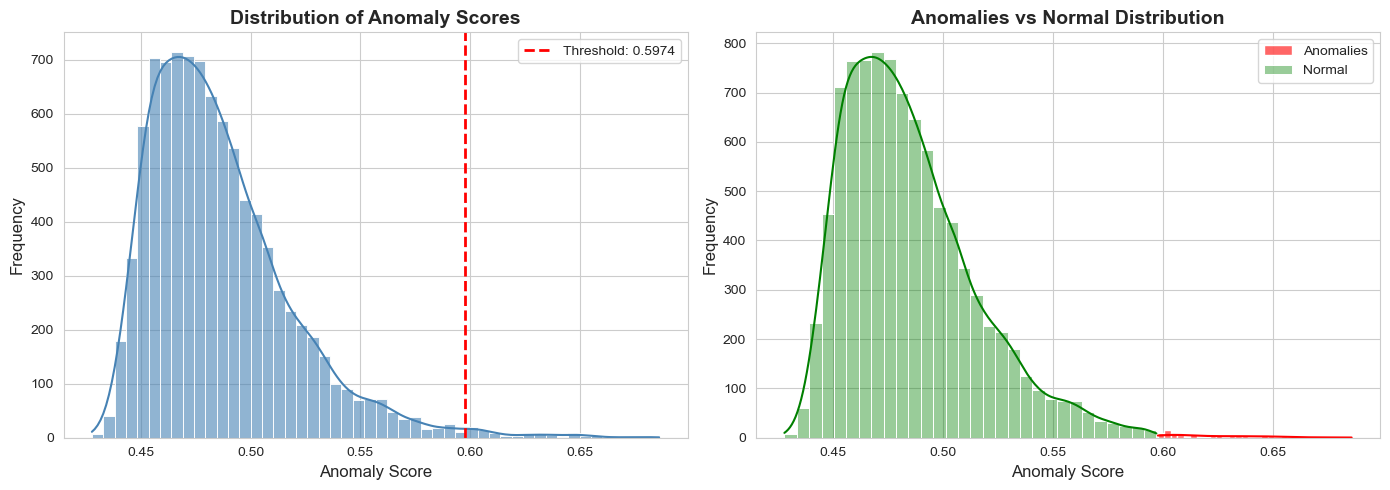

In [ ]:
# Plot anomaly score distribution
plt.figure(figsize=(14, 5))

# Overall distribution
plt.subplot(1, 2, 1)
sns.histplot(anomaly_scores, bins=50, kde=True, color='steelblue', alpha=0.6)
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel('Anomaly Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Anomaly Scores', fontsize=14, fontweight='bold')
plt.legend()

# Anomalies vs Normal
plt.subplot(1, 2, 2)
sns.histplot(df[df['Anomaly']==1]['Anomaly_Score'], bins=30, kde=True, 
             color='red', alpha=0.6, label='Anomalies')
sns.histplot(df[df['Anomaly']==0]['Anomaly_Score'], bins=30, kde=True, 
             color='green', alpha=0.4, label='Normal')
plt.xlabel('Anomaly Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Anomalies vs Normal Distribution', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

## 8. SHAP Integration: Initialize Explainer

Now we'll use SHAP to explain which features contribute most to anomaly detection.

In [ ]:
# Initialize SHAP explainer for our custom Isolation Forest
print("Initializing SHAP explainer...")
print("Note: This may take a few moments...\n")

# Use a smaller subset for SHAP background distribution (more efficient)
sample_for_shap = min(100, len(df_features))  # Reduced for efficiency
df_shap_sample = df_features.sample(n=sample_for_shap, random_state=42)

# Create SHAP KernelExplainer with limited samples for efficiency
# Use a wrapper function to ensure consistent output format
def model_predict(X):
    """Wrapper function for SHAP compatibility"""
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=df_features.columns)
    return iso_forest.anomaly_score(X)

explainer = shap.KernelExplainer(model_predict, df_shap_sample)

print(f"SHAP explainer initialized!")
print(f"Using {sample_for_shap} samples for background distribution")

Initializing SHAP explainer...
Note: This may take a few moments...

SHAP explainer initialized!
Using 100 samples for background distribution


In [ ]:
# Calculate SHAP values for a representative sample
print("Computing SHAP values...")
print("This step may take a few minutes...\n")

# Use smaller sample size for SHAP computation (50-100 instances is reasonable)
n_shap_samples = min(50, len(df_features))  # Reduced for efficiency
shap_indices = np.random.choice(len(df_features), n_shap_samples, replace=False)
df_shap_explain = df_features.iloc[shap_indices]

# Calculate SHAP values with fewer samples (nsamples="auto" or specific number)
# Lower nsamples = faster but less accurate
shap_values = explainer.shap_values(df_shap_explain, nsamples=100, silent=False)

print(f"\nSHAP values computed!")
print(f"Shape: {shap_values.shape}")
print(f"Samples analyzed: {n_shap_samples}")
print(f"Features analyzed: {list(df_features.columns)}")

Computing SHAP values...
This step may take a few minutes...



  0%|          | 0/50 [00:00<?, ?it/s]


SHAP values computed!
Shape: (50, 18)
Samples analyzed: 50
Features analyzed: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'weekday_sin', 'weekday_cos']


## 9. Overall Feature Importance Analysis

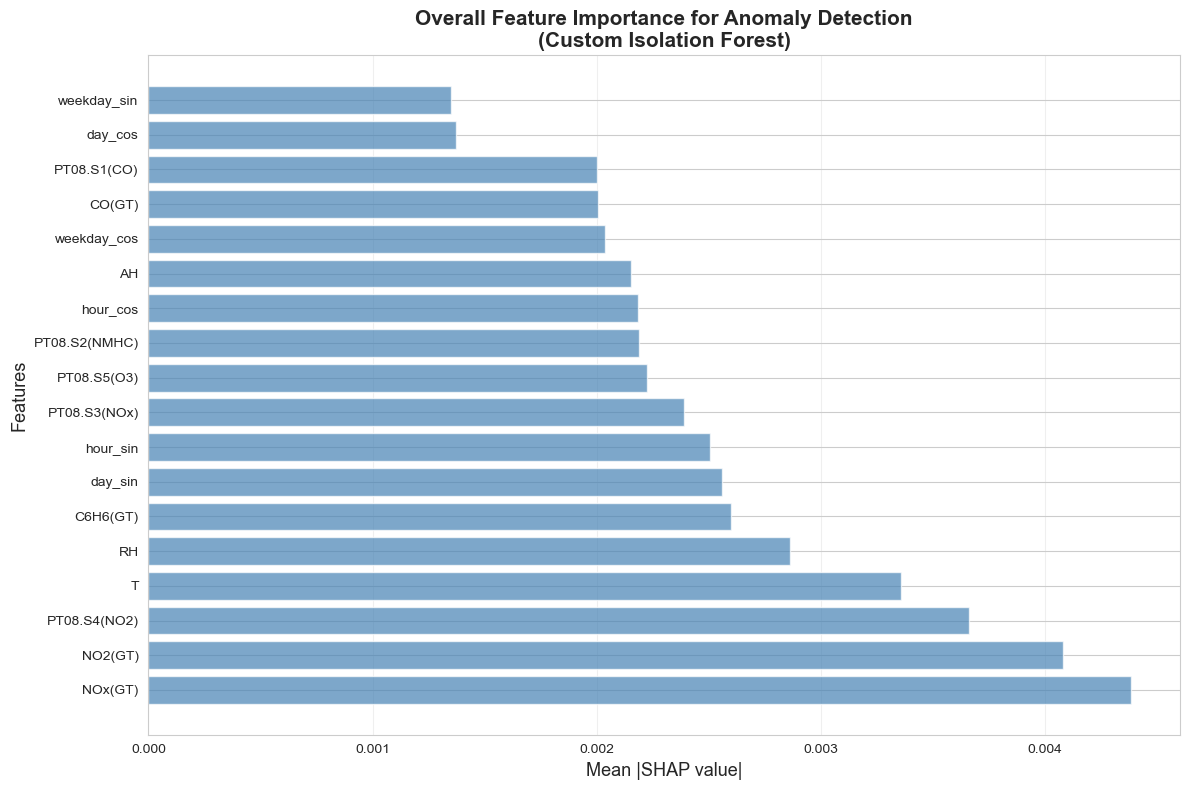


TOP 10 MOST IMPORTANT FEATURES FOR ANOMALY DETECTION
   1. NOx(GT)                  : 0.004383
   2. NO2(GT)                  : 0.004080
   3. PT08.S4(NO2)             : 0.003662
   4. T                        : 0.003359
   5. RH                       : 0.002861
   6. C6H6(GT)                 : 0.002599
   7. day_sin                  : 0.002559
   8. hour_sin                 : 0.002503
   9. PT08.S3(NOx)             : 0.002391
  10. PT08.S5(O3)              : 0.002223


In [ ]:
# Calculate mean absolute SHAP values for overall feature importance
features = df_features.columns
mean_shap_abs = np.abs(shap_values).mean(axis=0)

# Create feature importance plot
plt.figure(figsize=(12, 8))
sorted_idx = np.argsort(mean_shap_abs)[::-1]
plt.barh(range(len(features)), mean_shap_abs[sorted_idx], color='steelblue', alpha=0.7)
plt.yticks(range(len(features)), [features[i] for i in sorted_idx])
plt.xlabel('Mean |SHAP value|', fontsize=13)
plt.ylabel('Features', fontsize=13)
plt.title('Overall Feature Importance for Anomaly Detection\n(Custom Isolation Forest)', 
          fontsize=15, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print top features
print("\n" + "="*70)
print("TOP 10 MOST IMPORTANT FEATURES FOR ANOMALY DETECTION")
print("="*70)
for i in range(min(10, len(features))):
    print(f"  {i+1:2d}. {features[sorted_idx[i]]:25s}: {mean_shap_abs[sorted_idx[i]]:.6f}")

## 10. Feature Importance: Anomalies vs Normal Instances

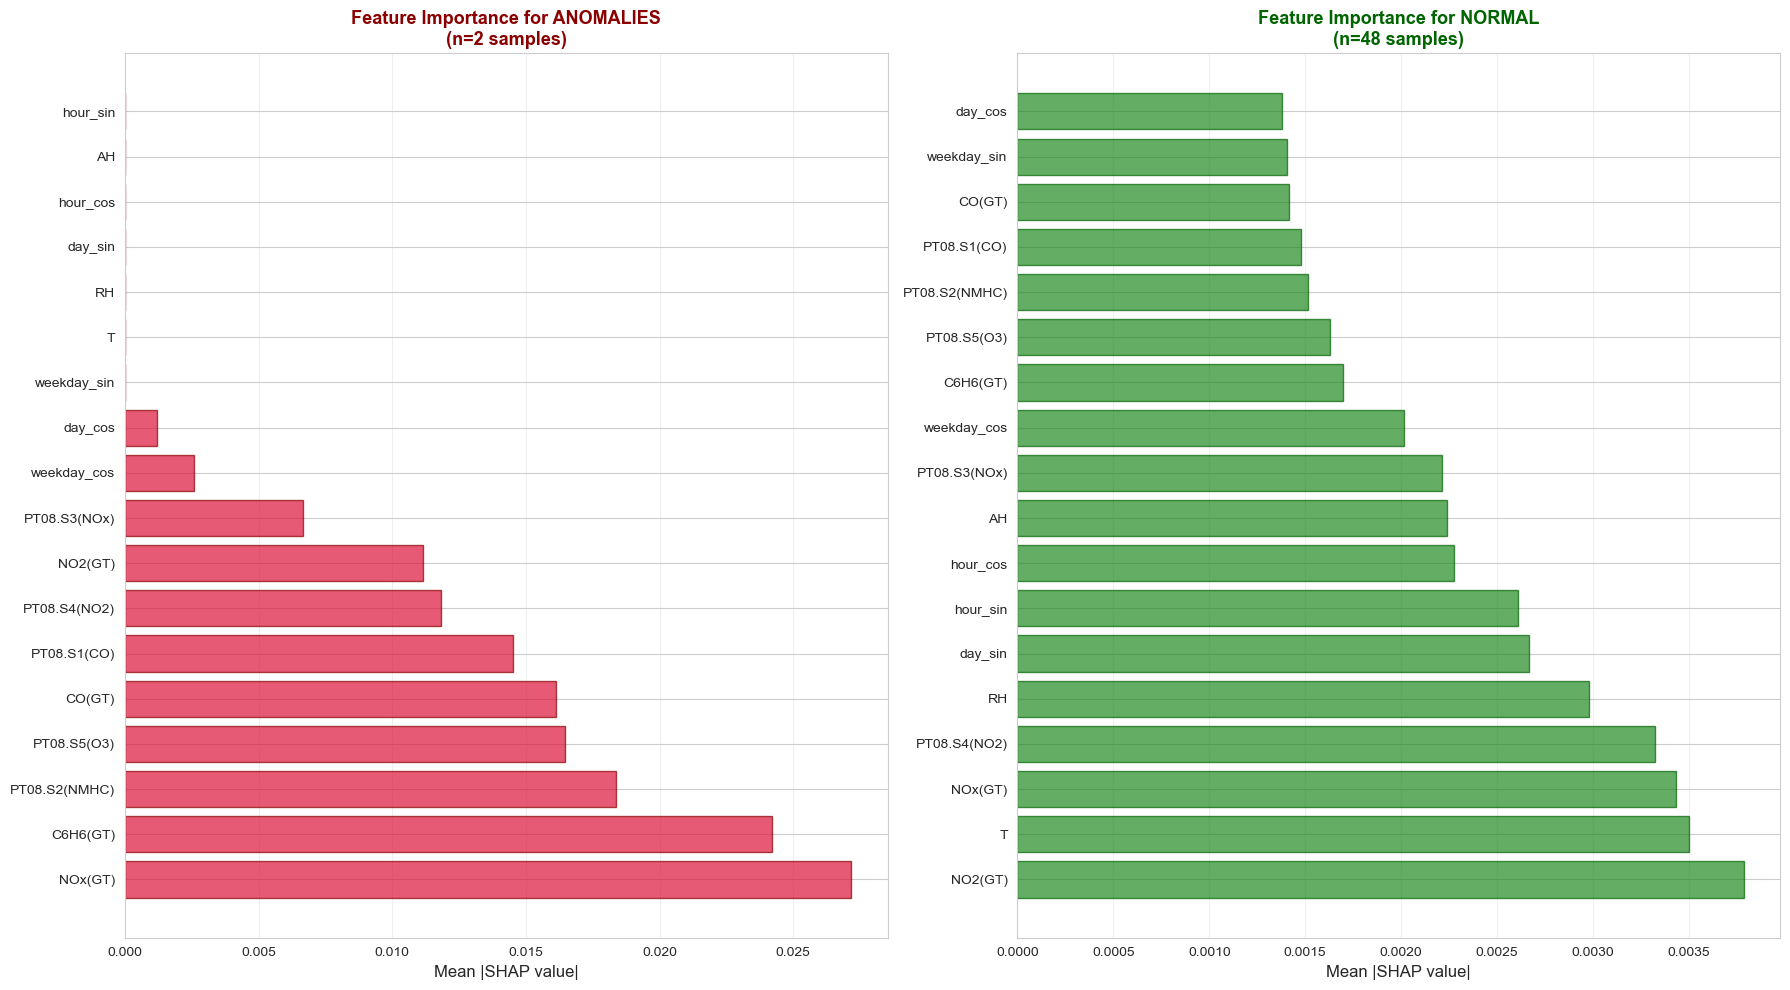


TOP 5 FEATURES DRIVING ANOMALIES:
  1. NOx(GT)                  : 0.027168
  2. C6H6(GT)                 : 0.024200
  3. PT08.S2(NMHC)            : 0.018359
  4. PT08.S5(O3)              : 0.016453
  5. CO(GT)                   : 0.016123

TOP 5 FEATURES FOR NORMAL INSTANCES:
  1. NO2(GT)                  : 0.003786
  2. T                        : 0.003499
  3. NOx(GT)                  : 0.003434
  4. PT08.S4(NO2)             : 0.003321
  5. RH                       : 0.002980


In [ ]:
# Separate SHAP values for anomalies vs normal instances
anomaly_mask_shap = df.iloc[shap_indices]['Anomaly'].values == 1
normal_mask_shap = df.iloc[shap_indices]['Anomaly'].values == 0

anomaly_shap_mean = np.abs(shap_values[anomaly_mask_shap]).mean(axis=0)
normal_shap_mean = np.abs(shap_values[normal_mask_shap]).mean(axis=0)

feature_names = list(df_features.columns)

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Anomalies
sorted_idx_anom = np.argsort(anomaly_shap_mean)[::-1]
axes[0].barh(range(len(feature_names)), anomaly_shap_mean[sorted_idx_anom], 
             color='crimson', alpha=0.7, edgecolor='darkred')
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels([feature_names[i] for i in sorted_idx_anom])
axes[0].set_xlabel('Mean |SHAP value|', fontsize=12)
axes[0].set_title(f'Feature Importance for ANOMALIES\n(n={sum(anomaly_mask_shap)} samples)', 
                  fontsize=13, fontweight='bold', color='darkred')
axes[0].grid(axis='x', alpha=0.3)

# Normal
sorted_idx_norm = np.argsort(normal_shap_mean)[::-1]
axes[1].barh(range(len(feature_names)), normal_shap_mean[sorted_idx_norm], 
             color='forestgreen', alpha=0.7, edgecolor='darkgreen')
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels([feature_names[i] for i in sorted_idx_norm])
axes[1].set_xlabel('Mean |SHAP value|', fontsize=12)
axes[1].set_title(f'Feature Importance for NORMAL\n(n={sum(normal_mask_shap)} samples)', 
                  fontsize=13, fontweight='bold', color='darkgreen')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\n" + "="*70)
print("TOP 5 FEATURES DRIVING ANOMALIES:")
print("="*70)
for i in range(min(5, len(feature_names))):
    feat = feature_names[sorted_idx_anom[i]]
    val = anomaly_shap_mean[sorted_idx_anom[i]]
    print(f"  {i+1}. {feat:25s}: {val:.6f}")

print("\n" + "="*70)
print("TOP 5 FEATURES FOR NORMAL INSTANCES:")
print("="*70)
for i in range(min(5, len(feature_names))):
    feat = feature_names[sorted_idx_norm[i]]
    val = normal_shap_mean[sorted_idx_norm[i]]
    print(f"  {i+1}. {feat:25s}: {val:.6f}")

## 11. Differential Feature Importance: What Makes Anomalies Different?

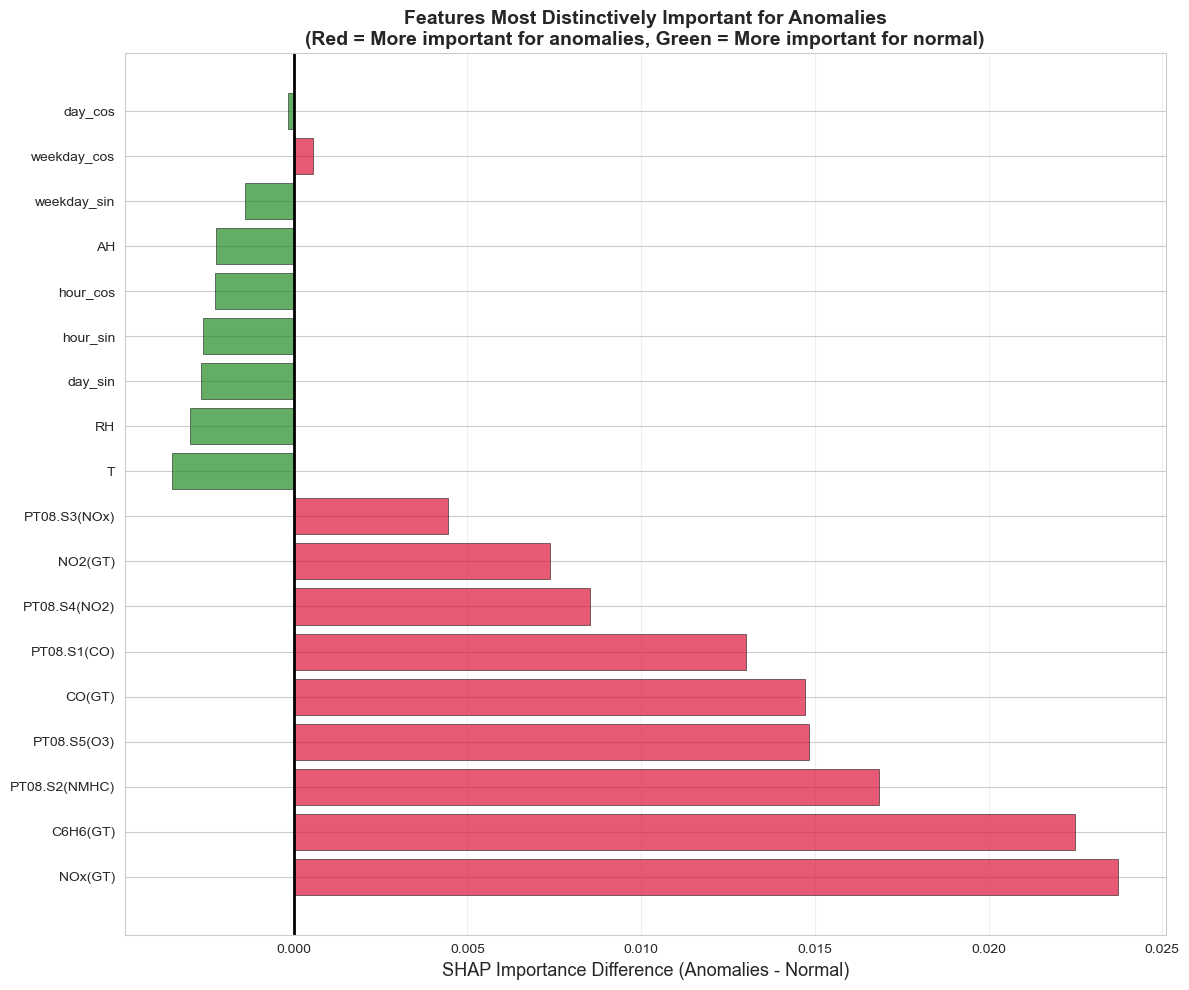


FEATURES MOST DISTINCTIVELY IMPORTANT FOR ANOMALIES:
Rank  Feature                         Difference     Anomaly      Normal
--------------------------------------------------------------------------------
1     NOx(GT)                          +0.023734    0.027168    0.003434
2     C6H6(GT)                         +0.022501    0.024200    0.001699
3     PT08.S2(NMHC)                    +0.016846    0.018359    0.001514
4     PT08.S5(O3)                      +0.014823    0.016453    0.001630
5     CO(GT)                           +0.014707    0.016123    0.001416
6     PT08.S1(CO)                      +0.013029    0.014508    0.001479
7     PT08.S4(NO2)                     +0.008522    0.011843    0.003321
8     NO2(GT)                          +0.007372    0.011158    0.003786


In [ ]:
# Calculate the difference in SHAP importance between anomalies and normal
shap_difference = anomaly_shap_mean - normal_shap_mean

# Sort by absolute difference
sorted_idx_diff = np.argsort(np.abs(shap_difference))[::-1]

plt.figure(figsize=(12, 10))
colors = ['crimson' if x > 0 else 'forestgreen' for x in shap_difference[sorted_idx_diff]]
plt.barh(range(len(feature_names)), shap_difference[sorted_idx_diff], 
         color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx_diff])
plt.xlabel('SHAP Importance Difference (Anomalies - Normal)', fontsize=13)
plt.title('Features Most Distinctively Important for Anomalies\n' +
          '(Red = More important for anomalies, Green = More important for normal)', 
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FEATURES MOST DISTINCTIVELY IMPORTANT FOR ANOMALIES:")
print("="*80)
print(f"{'Rank':<6}{'Feature':<30}{'Difference':>12}{'Anomaly':>12}{'Normal':>12}")
print("-"*80)
for i in range(min(8, len(feature_names))):
    feat = feature_names[sorted_idx_diff[i]]
    diff = shap_difference[sorted_idx_diff[i]]
    anom_val = anomaly_shap_mean[sorted_idx_diff[i]]
    norm_val = normal_shap_mean[sorted_idx_diff[i]]
    print(f"{i+1:<6}{feat:<30}{diff:>+12.6f}{anom_val:>12.6f}{norm_val:>12.6f}")

## 12. SHAP Summary Plots

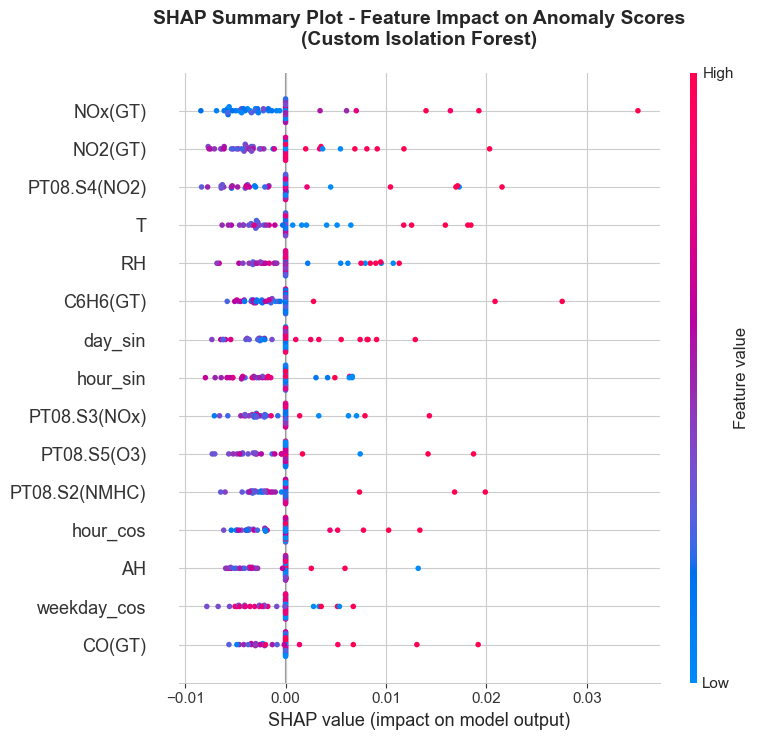

In [ ]:
# SHAP summary plot for all data (alternative to beeswarm for KernelExplainer)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_shap_explain, max_display=15, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Anomaly Scores\n(Custom Isolation Forest)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

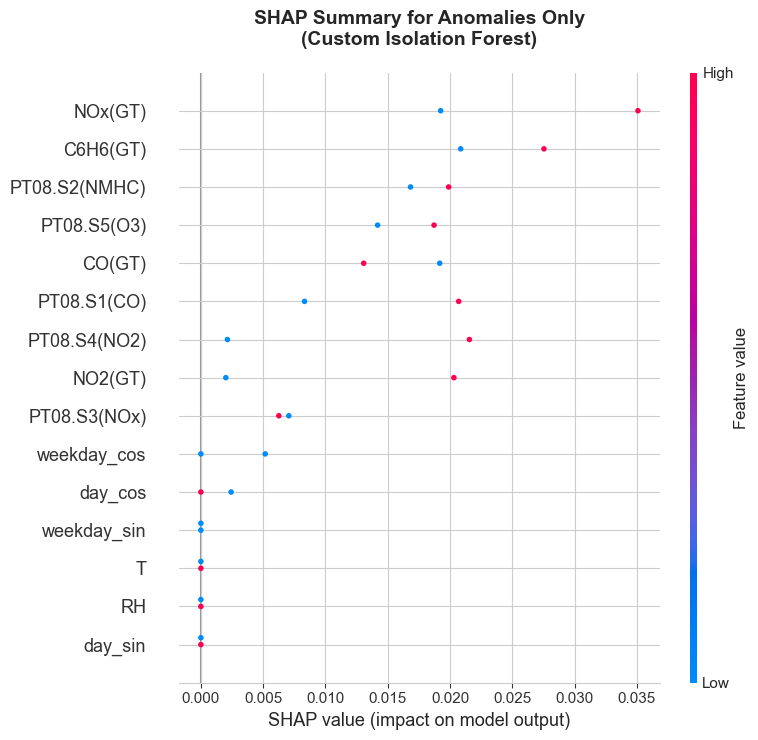

In [ ]:
# SHAP summary plot for anomalies only
if sum(anomaly_mask_shap) > 0:
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values[anomaly_mask_shap], 
                     df_shap_explain.iloc[anomaly_mask_shap], 
                     max_display=15,
                     show=False)
    plt.title('SHAP Summary for Anomalies Only\n(Custom Isolation Forest)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("No anomalies in the SHAP sample to visualize.")

## 13. Individual Instance Analysis: Waterfall Plots

Let's examine specific anomalous and normal instances to understand what makes them different.

In [ ]:
# Find the most anomalous and most normal instances in our SHAP sample
sample_scores = df.iloc[shap_indices]['Anomaly_Score'].values
sample_predictions = df.iloc[shap_indices]['Anomaly'].values

# Most anomalous instance (highest anomaly score)
anomaly_sample_indices = np.where(sample_predictions == 1)[0]
if len(anomaly_sample_indices) > 0:
    most_anomalous_local_idx = anomaly_sample_indices[np.argmax(sample_scores[anomaly_sample_indices])]
    most_anomalous_score = sample_scores[most_anomalous_local_idx]
    print(f"Most anomalous instance in sample: local index {most_anomalous_local_idx}")
    print(f"  Anomaly score: {most_anomalous_score:.6f}")
    print(f"  Global index: {shap_indices[most_anomalous_local_idx]}")
else:
    print("No anomalies found in SHAP sample")
    most_anomalous_local_idx = None

# Most normal instance (lowest anomaly score)
normal_sample_indices = np.where(sample_predictions == 0)[0]
if len(normal_sample_indices) > 0:
    most_normal_local_idx = normal_sample_indices[np.argmin(sample_scores[normal_sample_indices])]
    most_normal_score = sample_scores[most_normal_local_idx]
    print(f"\nMost normal instance in sample: local index {most_normal_local_idx}")
    print(f"  Anomaly score: {most_normal_score:.6f}")
    print(f"  Global index: {shap_indices[most_normal_local_idx]}")
else:
    print("No normal instances found in SHAP sample")
    most_normal_local_idx = None

Most anomalous instance in sample: local index 28
  Anomaly score: 0.645998
  Global index: 5495

Most normal instance in sample: local index 41
  Anomaly score: 0.444442
  Global index: 6305



SHAP Explanation for MOST ANOMALOUS Instance
Anomaly Score: 0.645998



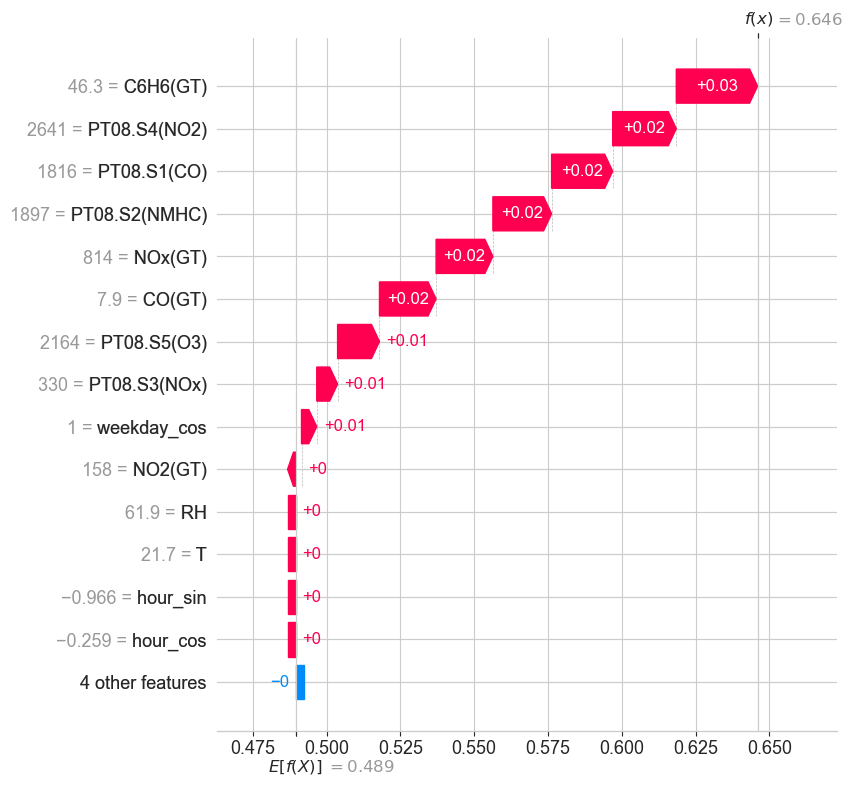


Feature values for this anomalous instance:
  CO(GT)                   :     7.9000
  PT08.S1(CO)              :  1816.0000
  C6H6(GT)                 :    46.3000
  PT08.S2(NMHC)            :  1897.0000
  NOx(GT)                  :   814.0000
  PT08.S3(NOx)             :   330.0000
  NO2(GT)                  :   158.0000
  PT08.S4(NO2)             :  2641.0000
  PT08.S5(O3)              :  2164.0000
  T                        :    21.7000
  RH                       :    61.9000
  AH                       :     1.5920
  hour_sin                 :    -0.9659
  hour_cos                 :    -0.2588
  day_sin                  :    -0.9378
  day_cos                  :     0.3473
  weekday_sin              :     0.0000
  weekday_cos              :     1.0000


In [ ]:
# Waterfall plot for most anomalous instance
if most_anomalous_local_idx is not None:
    print(f"\n{'='*70}")
    print(f"SHAP Explanation for MOST ANOMALOUS Instance")
    print(f"{'='*70}")
    print(f"Anomaly Score: {most_anomalous_score:.6f}\n")
    
    # Create SHAP Explanation object for waterfall plot
    shap_exp = shap.Explanation(values=shap_values[most_anomalous_local_idx],
                                base_values=explainer.expected_value,
                                data=df_shap_explain.iloc[most_anomalous_local_idx].values,
                                feature_names=list(df_features.columns))
    shap.waterfall_plot(shap_exp, max_display=15)
    
    # Show feature values for this instance
    print("\nFeature values for this anomalous instance:")
    instance_data = df_shap_explain.iloc[most_anomalous_local_idx]
    for feat, val in instance_data.items():
        print(f"  {feat:25s}: {val:10.4f}")


SHAP Explanation for MOST NORMAL Instance
Anomaly Score: 0.444442



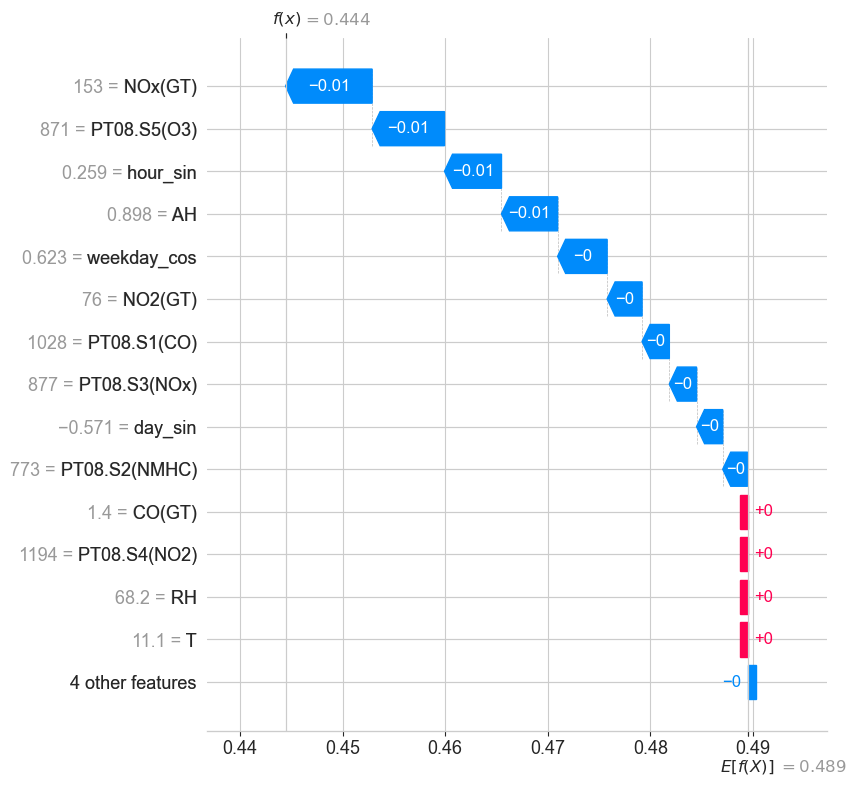


Feature values for this normal instance:
  CO(GT)                   :     1.4000
  PT08.S1(CO)              :  1028.0000
  C6H6(GT)                 :     5.2000
  PT08.S2(NMHC)            :   773.0000
  NOx(GT)                  :   153.0000
  PT08.S3(NOx)             :   877.0000
  NO2(GT)                  :    76.0000
  PT08.S4(NO2)             :  1194.0000
  PT08.S5(O3)              :   871.0000
  T                        :    11.1000
  RH                       :    68.2000
  AH                       :     0.8979
  hour_sin                 :     0.2588
  hour_cos                 :    -0.9659
  day_sin                  :    -0.5713
  day_cos                  :     0.8208
  weekday_sin              :    -0.7818
  weekday_cos              :     0.6235


In [ ]:
# Waterfall plot for most normal instance
if most_normal_local_idx is not None:
    print(f"\n{'='*70}")
    print(f"SHAP Explanation for MOST NORMAL Instance")
    print(f"{'='*70}")
    print(f"Anomaly Score: {most_normal_score:.6f}\n")
    
    # Create SHAP Explanation object for waterfall plot
    shap_exp = shap.Explanation(values=shap_values[most_normal_local_idx],
                                base_values=explainer.expected_value,
                                data=df_shap_explain.iloc[most_normal_local_idx].values,
                                feature_names=list(df_features.columns))
    shap.waterfall_plot(shap_exp, max_display=15)
    
    # Show feature values for this instance
    print("\nFeature values for this normal instance:")
    instance_data = df_shap_explain.iloc[most_normal_local_idx]
    for feat, val in instance_data.items():
        print(f"  {feat:25s}: {val:10.4f}")

## 14. Feature Value Analysis: Anomalies vs Normal

In [ ]:
# Compare feature statistics between anomalies and normal instances
anomaly_data = df_features[df['Anomaly'] == 1]
normal_data = df_features[df['Anomaly'] == 0]

print("\n" + "="*90)
print("FEATURE VALUE COMPARISON: ANOMALIES vs NORMAL")
print("="*90)
print(f"{'Feature':<25}{'Anomaly Mean':>15}{'Normal Mean':>15}{'Difference':>15}{'% Diff':>15}")
print("-"*90)

for feat in df_features.columns:
    anom_mean = anomaly_data[feat].mean()
    norm_mean = normal_data[feat].mean()
    diff = anom_mean - norm_mean
    if norm_mean != 0:
        pct_diff = (diff / abs(norm_mean)) * 100
    else:
        pct_diff = 0
    print(f"{feat:<25}{anom_mean:>15.4f}{norm_mean:>15.4f}{diff:>+15.4f}{pct_diff:>+14.2f}%")


FEATURE VALUE COMPARISON: ANOMALIES vs NORMAL
Feature                     Anomaly Mean    Normal Mean     Difference         % Diff
------------------------------------------------------------------------------------------
CO(GT)                            7.1313         2.0799        +5.0515       +242.88%
PT08.S1(CO)                    1727.0522      1096.7275      +630.3247        +57.47%
C6H6(GT)                         36.6680         9.9103       +26.7577       +270.00%
PT08.S2(NMHC)                  1691.1002       934.5423      +756.5580        +80.95%
NOx(GT)                         867.3810       235.5751      +631.8059       +268.20%
PT08.S3(NOx)                    407.7759       837.0716      -429.2957        -51.29%
NO2(GT)                         195.1239       108.7645       +86.3594        +79.40%
PT08.S4(NO2)                   2203.0297      1445.6906      +757.3390        +52.39%
PT08.S5(O3)                    2114.3982      1021.5658     +1092.8325       +106.98%
T 

## 15. Temporal Visualization: Anomalies Over Time

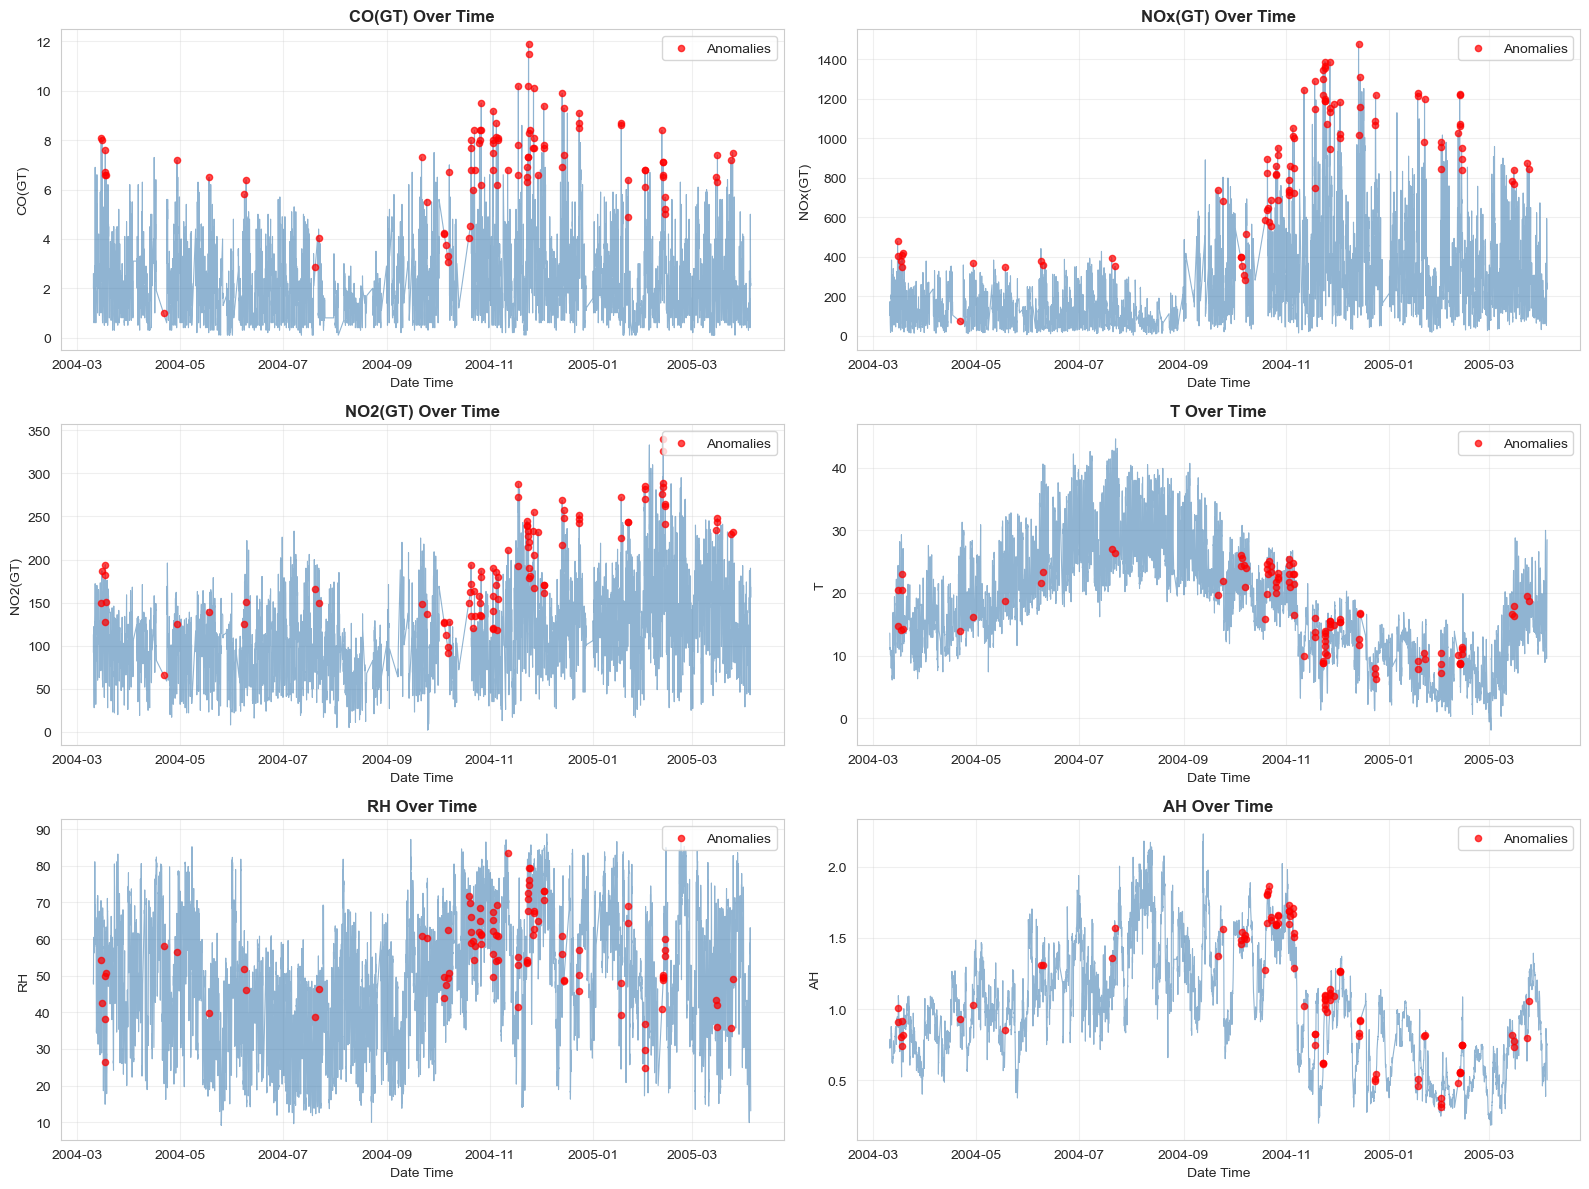

In [ ]:
# Ensure Date_Time is in datetime format
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

# Plot a few key features over time with anomalies highlighted
key_features = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']
anomalies = df[df['Anomaly'] == 1]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if feature in df.columns:
        # Plot the feature over time
        axes[i].plot(df['Date_Time'], df[feature], alpha=0.6, linewidth=0.8, color='steelblue')
        
        # Highlight anomalies
        axes[i].scatter(anomalies['Date_Time'], anomalies[feature], 
                       color='red', s=20, alpha=0.7, label='Anomalies', zorder=5)
        
        axes[i].set_xlabel('Date Time', fontsize=10)
        axes[i].set_ylabel(feature, fontsize=10)
        axes[i].set_title(f'{feature} Over Time', fontsize=12, fontweight='bold')
        axes[i].legend(loc='upper right')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 16. SHAP Dependence Plots for Top Features

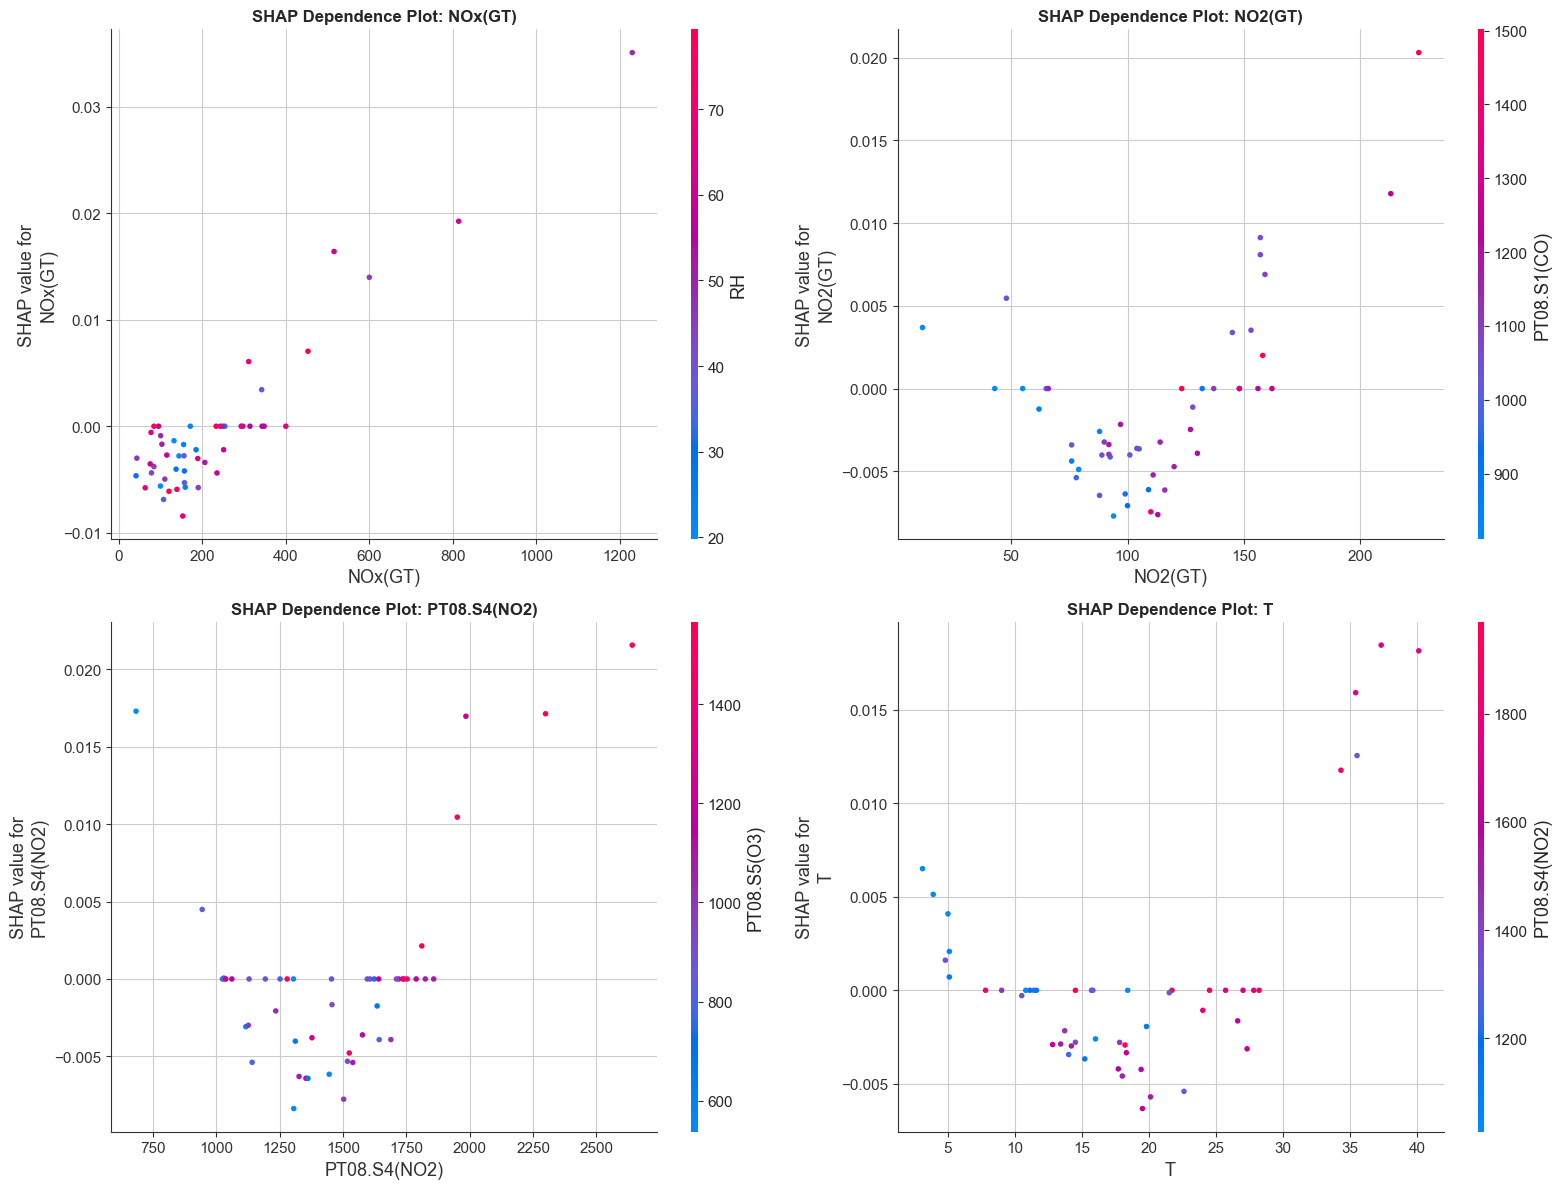

In [ ]:
# Create SHAP dependence plots for the top 4 features
top_n = 4
top_features = [features[i] for i in sorted_idx[:top_n]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    feature_idx = list(features).index(feature)
    shap.dependence_plot(feature_idx, shap_values, df_shap_explain, 
                        feature_names=features, ax=axes[i], show=False)
    axes[i].set_title(f'SHAP Dependence Plot: {feature}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 17. Final Summary and Insights

In [ ]:
# Generate comprehensive summary
print("\n" + "="*80)
print(" "*20 + "ANOMALY DETECTION SUMMARY")
print("="*80)

print("\n1. DATASET INFORMATION:")
print(f"   Total instances: {len(df):,}")
print(f"   Features used: {df_features.shape[1]}")
print(f"   Date range: {df['Date_Time'].min()} to {df['Date_Time'].max()}")

print("\n2. MODEL CONFIGURATION:")
print(f"   Algorithm: Custom Isolation Forest")
print(f"   Number of trees: {n_trees}")
print(f"   Sample size per tree: {sample_size}")
print(f"   Contamination rate: {contamination * 100:.1f}%")

print("\n3. DETECTION RESULTS:")
print(f"   Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)")
print(f"   Normal instances: {n_normal:,} ({n_normal/len(df)*100:.2f}%)")
print(f"   Anomaly threshold: {threshold:.6f}")

print("\n4. ANOMALY SCORE STATISTICS:")
print(f"   Overall range: [{df['Anomaly_Score'].min():.6f}, {df['Anomaly_Score'].max():.6f}]")
print(f"   Anomalies - Mean: {df[df['Anomaly']==1]['Anomaly_Score'].mean():.6f}, "
      f"Std: {df[df['Anomaly']==1]['Anomaly_Score'].std():.6f}")
print(f"   Normal    - Mean: {df[df['Anomaly']==0]['Anomaly_Score'].mean():.6f}, "
      f"Std: {df[df['Anomaly']==0]['Anomaly_Score'].std():.6f}")

print("\n5. TOP 5 FEATURES EXPLAINING ANOMALIES (via SHAP):")
for i in range(min(5, len(features))):
    feat = features[sorted_idx[i]]
    importance = mean_shap_abs[sorted_idx[i]]
    print(f"   {i+1}. {feat:30s} - SHAP Importance: {importance:.6f}")

print("\n6. KEY INSIGHTS:")
print("   " + "-"*76)
# Identify features with large differences between anomalies and normal
if len(anomaly_sample_indices) > 0 and len(normal_sample_indices) > 0:
    top_diff_features = [feature_names[i] for i in sorted_idx_diff[:3]]
    print(f"   - Features most distinctive for anomalies: {', '.join(top_diff_features)}")
    print(f"   - Anomalous instances show unusual patterns in {top_diff_features[0]}")
    print(f"   - SHAP analysis reveals complex interactions between features")

print("\n" + "="*80)
print(" "*25 + "ANALYSIS COMPLETE")
print("="*80)


                    ANOMALY DETECTION SUMMARY

1. DATASET INFORMATION:
   Total instances: 9,357
   Features used: 18
   Date range: 2004-03-10 18:00:00 to 2005-04-04 14:00:00

2. MODEL CONFIGURATION:
   Algorithm: Custom Isolation Forest
   Number of trees: 100
   Sample size per tree: 256
   Contamination rate: 1.0%

3. DETECTION RESULTS:
   Anomalies detected: 94 (1.00%)
   Normal instances: 9,263 (99.00%)
   Anomaly threshold: 0.597352

4. ANOMALY SCORE STATISTICS:
   Overall range: [0.427847, 0.685871]
   Anomalies - Mean: 0.623095, Std: 0.022219
   Normal    - Mean: 0.484753, Std: 0.029593

5. TOP 5 FEATURES EXPLAINING ANOMALIES (via SHAP):
   1. NOx(GT)                        - SHAP Importance: 0.004383
   2. NO2(GT)                        - SHAP Importance: 0.004080
   3. PT08.S4(NO2)                   - SHAP Importance: 0.003662
   4. T                              - SHAP Importance: 0.003359
   5. RH                             - SHAP Importance: 0.002861

6. KEY INSIGHTS:
 

## Conclusion

This notebook has successfully demonstrated:

1. **Custom Isolation Forest Implementation**: Used the custom implementation from `isolation_forest.py` to detect anomalies in air quality data

2. **SHAP Integration**: Integrated SHAP explanations to provide interpretability for anomaly detection results

3. **Feature Importance Analysis**: Identified which features are most important for detecting anomalies and how they differ from normal instances

4. **Individual Instance Explanations**: Examined specific anomalous cases to understand what makes them unusual

5. **Comparative Analysis**: Highlighted the differences in feature importance between anomalies and normal instances

The combination of Isolation Forest and SHAP provides both powerful anomaly detection and clear explanations of why certain instances are flagged as anomalous, making the model more trustworthy and actionable.